# Synthetic Music Streams — A Data-Generating Process (DGP)

A self-contained, reproducible **DGP for music releases and their daily streams**,
followed by time-series plots and descriptive statistics.

The point is to generate a panel that *looks like* real streaming data so you can
play with it: catalog growth over time, release spikes that decay, weekend
seasonality, the occasional viral hit, and the brutal concentration where a
handful of tracks capture most of the streams.

---

## The model

We observe **artists**, each releasing one or more **tracks**, and we record the
**daily streams** of every track from its release date to the end of the window.

For track $i$ on calendar day with weekday $w$, let $a$ be days since release.
Expected streams are

$$
\mu_{i,a} \;=\; \underbrace{P_{\text{artist}(i)}\cdot Q_i}_{\text{peak level }\beta_i}
\;\times\; \underbrace{e^{-\lambda_i a}}_{\text{decay}}
\;\times\; \underbrace{s_w}_{\text{day-of-week}}
\;\times\; \underbrace{\bigl(1+v_{i,a}\bigr)}_{\text{viral bump}}
$$

and observed streams are an **over-dispersed count**

$$
y_{i,a}\ \sim\ \text{NegBinomial}(\text{mean}=\mu_{i,a},\ r),\qquad
\operatorname{Var}(y)=\mu+\mu^2/r .
$$

**Ingredients (all heterogeneous and log-normal where it matters):**

| Component | Symbol | Meaning |
|---|---|---|
| Artist popularity | $P$ | log-normal; sets each artist's scale |
| Track quality | $Q$ | log-normal; some tracks are hits, most are not |
| Peak level | $\beta_i=P\cdot Q$ | expected day-0 streams |
| Decay rate | $\lambda_i=\ln 2/h_i$ | half-life $h_i$ log-normal; better tracks decay a bit slower |
| Day-of-week | $s_w$ | weekly seasonality, **Friday / weekend lift** |
| Viral bump | $v_{i,a}$ | rare transient shocks (playlist / TikTok), exponential fade |
| Over-dispersion | $r$ | NegBinomial; real counts are spikier than Poisson |

The combination of log-normal $P\cdot Q$ **and** viral shocks is what produces the
realistic **concentration** (a few hits dominate), which we measure with a Gini
coefficient and a Lorenz curve below.


## 1 · Setup & parameters

Everything is driven by the seed and the `P` config block — change them and re-run the whole notebook to get a new world.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

SEED = 42
rng = np.random.default_rng(SEED)

# ----- DGP configuration -------------------------------------------------
P = dict(
    n_artists      = 30,            # number of artists
    tracks_lambda  = 3.0,           # avg tracks per artist (Poisson + 1)
    start          = "2024-01-01",  # observation window
    end            = "2025-12-31",
    min_observed   = 14,            # don't release a track in the last N days

    # artist popularity  P ~ LogNormal  -> median e^mu peak streams
    pop_mu         = np.log(2000),
    pop_sigma      = 1.0,

    # track quality  Q ~ LogNormal (median 1; right tail = hits)
    qual_mu        = 0.0,
    qual_sigma     = 0.85,

    # decay half-life (days); better tracks decay a touch slower
    halflife_med   = 25.0,
    halflife_sigma = 0.40,
    halflife_qual_beta = 0.15,      # elasticity of half-life to log-quality

    # day-of-week multipliers, Mon..Sun  (Fri / weekend lift). Normalised to mean 1.
    dow_raw        = np.array([0.95, 0.93, 0.95, 1.00, 1.18, 1.14, 1.06]),

    # viral shocks
    viral_p_track  = 0.30,          # P(a track ever goes viral)
    viral_n_lambda = 1.2,           # avg # of shocks given it goes viral
    viral_mag_lo   = 3.0,           # multiplicative bump magnitude range
    viral_mag_hi   = 18.0,
    viral_tau      = 9.0,           # bump fade time-constant (days)

    # NegBinomial over-dispersion (smaller = spikier)
    nb_r           = 6.0,
)

dates = pd.date_range(P["start"], P["end"], freq="D")
n_days = len(dates)
dow_mult = P["dow_raw"] / P["dow_raw"].mean()
print(f"Observation window: {dates[0].date()} -> {dates[-1].date()}  ({n_days} days)")
print("Day-of-week multipliers (Mon..Sun):", np.round(dow_mult, 3))

Observation window: 2024-01-01 -> 2025-12-31  (731 days)
Day-of-week multipliers (Mon..Sun): [0.922 0.903 0.922 0.971 1.146 1.107 1.029]


## 2 · Generate releases

Each artist gets a latent popularity and a random number of tracks; each track gets a quality, a release date, and a decay half-life.

In [2]:
# --- artists ---
artist_pop = rng.lognormal(P["pop_mu"], P["pop_sigma"], size=P["n_artists"])
artist_ids = [f"A{idx:02d}" for idx in range(P["n_artists"])]

# --- tracks per artist ---
rows = []
release_lo = dates[0]
release_hi = dates[-1] - pd.Timedelta(days=P["min_observed"])
release_span = (release_hi - release_lo).days

tid = 0
for aidx, aid in enumerate(artist_ids):
    n_tracks = 1 + rng.poisson(P["tracks_lambda"])
    for _ in range(n_tracks):
        quality = rng.lognormal(P["qual_mu"], P["qual_sigma"])
        peak = artist_pop[aidx] * quality                 # beta_i (expected day-0)
        # half-life: log-normal, mildly increasing in quality
        hl = (P["halflife_med"]
              * np.exp(P["halflife_qual_beta"] * np.log(quality))
              * np.exp(rng.normal(0, P["halflife_sigma"])))
        rel = release_lo + pd.Timedelta(days=int(rng.integers(0, release_span + 1)))
        rows.append(dict(track_id=f"T{tid:03d}", artist_id=aid,
                         artist_pop=artist_pop[aidx], quality=quality,
                         peak=peak, half_life=hl, release_date=rel))
        tid += 1

tracks = pd.DataFrame(rows)
print(f"{P['n_artists']} artists, {len(tracks)} tracks")
tracks.head()

30 artists, 110 tracks


,track_id,artist_id,artist_pop,quality,peak,half_life,release_date
0,T000,A00,2712.482481,2.610721,7081.535120,27.584136,2025-05-07
1,T001,A00,2712.482481,0.496184,1345.889627,29.194828,2024-12-07
2,T002,A00,2712.482481,1.880929,5101.988195,34.154776,2025-07-04
3,T003,A00,2712.482481,1.218155,3304.223124,26.981480,2025-08-19
4,T004,A00,2712.482481,1.204284,3266.599604,36.427724,2025-04-01


## 3 · Generate daily streams

For every track we walk forward from its release date, apply decay × seasonality × viral bumps to get the mean $\mu$, then draw an over-dispersed count.

In [3]:
def viral_bump(n_obs, track_rng):
    '''Transient multiplicative bumps v_{i,a}; returns array over a=0..n_obs-1.'''
    bump = np.zeros(n_obs)
    if track_rng.random() >= P["viral_p_track"]:
        return bump
    n_shocks = 1 + track_rng.poisson(P["viral_n_lambda"])
    a = np.arange(n_obs)
    for _ in range(n_shocks):
        t0 = track_rng.integers(0, n_obs)
        mag = track_rng.uniform(P["viral_mag_lo"], P["viral_mag_hi"])
        bump += np.where(a >= t0, mag * np.exp(-(a - t0) / P["viral_tau"]), 0.0)
    return bump

def nb_draw(mu, r, gen):
    '''NegBinomial with given mean mu and dispersion r (mean preserved).'''
    mu = np.maximum(mu, 1e-6)
    p = r / (r + mu)
    return gen.negative_binomial(r, p)

panel = []
for _, tr in tracks.iterrows():
    rel = tr.release_date
    obs_dates = dates[dates >= rel]
    a = np.arange(len(obs_dates))                       # days since release
    wd = obs_dates.weekday.to_numpy()
    lam = np.log(2) / tr.half_life

    track_rng = np.random.default_rng(abs(hash(tr.track_id)) % (2**32))
    mu = (tr.peak
          * np.exp(-lam * a)
          * dow_mult[wd]
          * (1.0 + viral_bump(len(a), track_rng)))
    y = nb_draw(mu, P["nb_r"], track_rng)

    panel.append(pd.DataFrame(dict(
        date=obs_dates, track_id=tr.track_id, artist_id=tr.artist_id,
        days_since_release=a, streams=y, mu=mu)))

panel = pd.concat(panel, ignore_index=True)
panel = panel.sort_values(["date", "track_id"]).reset_index(drop=True)
print(f"Panel: {len(panel):,} track-day observations")
panel.head()

Panel: 40,701 track-day observations


,date,track_id,artist_id,days_since_release,streams,mu
0,2024-01-06,T088,A24,0,647,828.467518
1,2024-01-07,T088,A24,1,375,755.846100
2,2024-01-08,T088,A24,2,595,664.672933
3,2024-01-09,T088,A24,3,443,638.446065
4,2024-01-10,T088,A24,4,260,639.914201


## 4 · The panel at a glance

In [4]:
total_streams = panel.streams.sum()
summary = pd.Series({
    "Artists":              tracks.artist_id.nunique(),
    "Tracks":               tracks.track_id.nunique(),
    "Days observed":        n_days,
    "Track-day rows":       len(panel),
    "Total streams":        int(total_streams),
    "Mean streams / row":   panel.streams.mean(),
    "Median streams / row": panel.streams.median(),
    "Max single-day":       int(panel.streams.max()),
})
display(summary.to_frame("value").style.format({"value": "{:,.2f}"}))

,value
Artists,30.00
Tracks,110.00
Days observed,731.00
Track-day rows,"40,701.00"
Total streams,"21,608,705.00"
Mean streams / row,530.91
Median streams / row,8.00
Max single-day,"113,582.00"


## 5 · Time series

### 5.1 Catalog-level: total daily streams

As releases accumulate the catalog grows; weekly seasonality shows up as the high-frequency ripple.

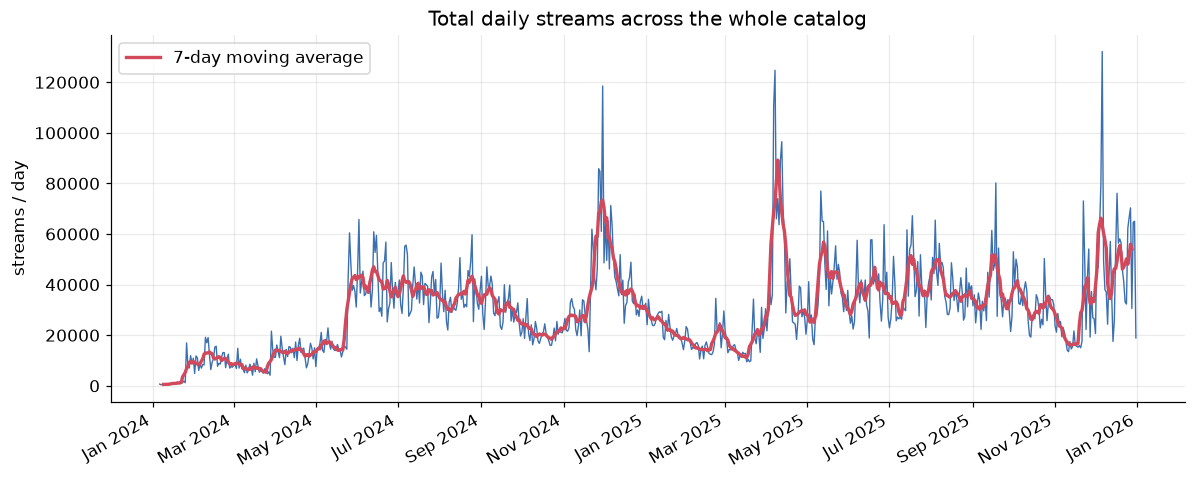

In [5]:
daily_total = panel.groupby("date").streams.sum()

fig, ax = plt.subplots()
ax.plot(daily_total.index, daily_total.values, lw=0.9, color="#3b6fb0")
ax.plot(daily_total.index, daily_total.rolling(7, center=True).mean(),
        lw=2.2, color="#d1495b", label="7-day moving average")
ax.set_title("Total daily streams across the whole catalog")
ax.set_ylabel("streams / day"); ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 5.2 Track-level trajectories

A hit, a typical track, and a flop — note the release spike, the exponential decay, and any viral bumps. Log scale on the right makes the decay roughly linear.

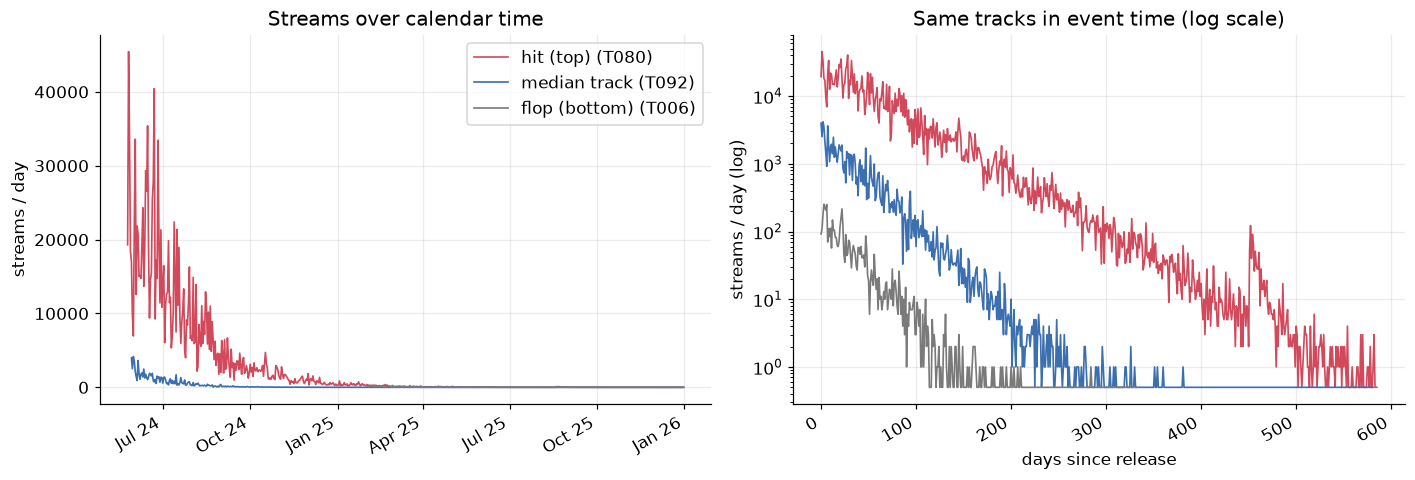

In [6]:
totals = panel.groupby("track_id").streams.sum().sort_values()
picks = {
    "hit (top)":      totals.index[-1],
    "median track":   totals.index[len(totals)//2],
    "flop (bottom)":  totals.index[0],
}
colors = {"hit (top)": "#d1495b", "median track": "#3b6fb0", "flop (bottom)": "#7a7a7a"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for label, tid in picks.items():
    d = panel[panel.track_id == tid]
    ax1.plot(d.date, d.streams, lw=1.1, color=colors[label], label=f"{label} ({tid})")
    ax2.plot(d.days_since_release, d.streams.clip(lower=0.5), lw=1.1, color=colors[label])
ax1.set_title("Streams over calendar time"); ax1.set_ylabel("streams / day"); ax1.legend()
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax2.set_yscale("log"); ax2.set_title("Same tracks in event time (log scale)")
ax2.set_xlabel("days since release"); ax2.set_ylabel("streams / day (log)")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 6 · Decay structure (event time)

Averaging across all tracks by *days since release* recovers the exponential decay we built in. Fitting a line to the log of the mean gives the implied catalog half-life.

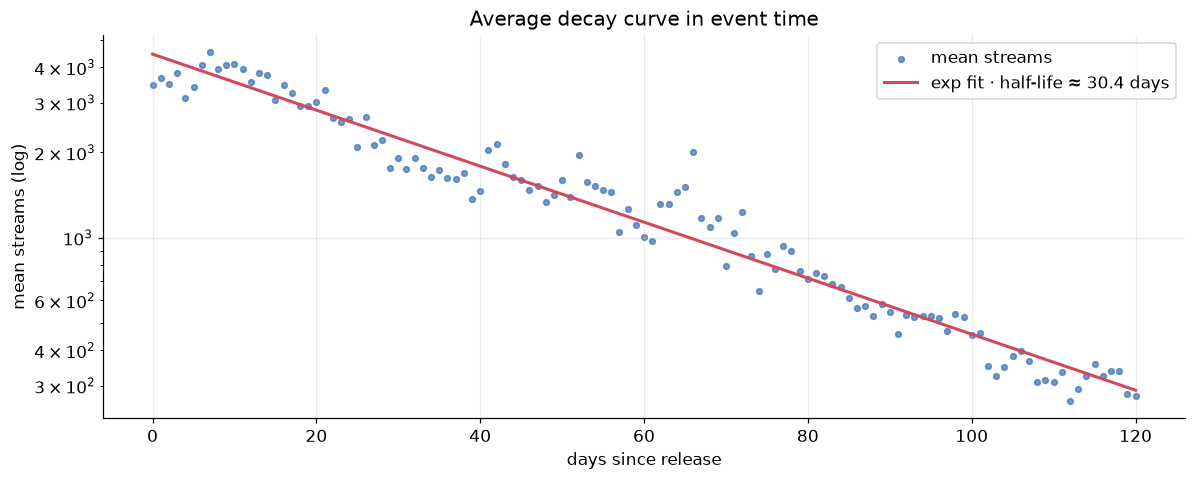

Implied catalog half-life: 30.4 days (median input half-life was 27.0 days)


In [7]:
HORIZON = 120
ev = (panel[panel.days_since_release <= HORIZON]
      .groupby("days_since_release").streams.mean())

a = ev.index.to_numpy()
slope, intercept = np.polyfit(a, np.log(ev.values), 1)
implied_hl = np.log(2) / (-slope)
fit = np.exp(intercept + slope * a)

fig, ax = plt.subplots()
ax.scatter(a, ev.values, s=14, color="#3b6fb0", alpha=0.7, label="mean streams")
ax.plot(a, fit, color="#d1495b", lw=2,
        label=f"exp fit · half-life ≈ {implied_hl:,.1f} days")
ax.set_yscale("log"); ax.set_title("Average decay curve in event time")
ax.set_xlabel("days since release"); ax.set_ylabel("mean streams (log)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Implied catalog half-life: {implied_hl:,.1f} days "
      f"(median input half-life was {tracks.half_life.median():,.1f} days)")

## 7 · Day-of-week seasonality

Residualised against each track's own mean so the weekly pattern isn't swamped by level differences. The **Friday / weekend lift** is the signal we injected.

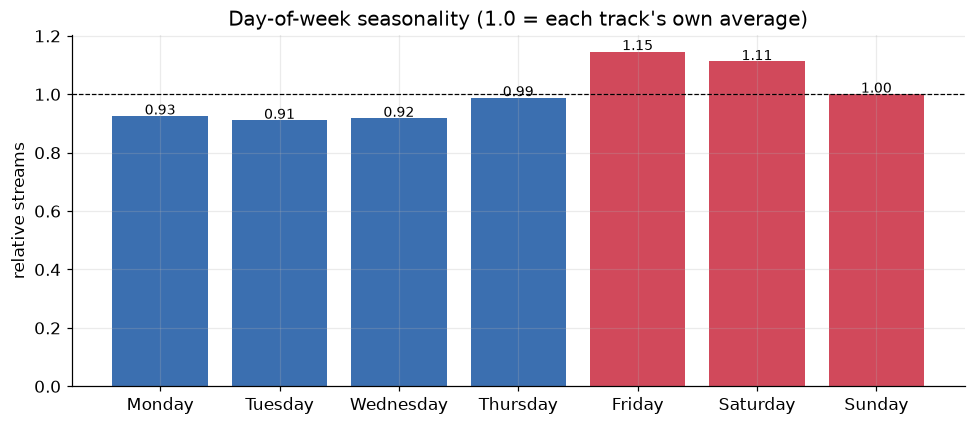

Weekend/Fri vs Mon-Thu lift: 16.1%


In [8]:
tmp = panel.copy()
tmp["weekday"] = pd.Categorical(
    tmp.date.dt.day_name(),
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    ordered=True)
tmp["rel"] = tmp.streams / tmp.groupby("track_id").streams.transform("mean")
dow = tmp.groupby("weekday", observed=True).rel.mean()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow.index.astype(str), dow.values,
              color=["#3b6fb0"]*4 + ["#d1495b"]*3)
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_title("Day-of-week seasonality (1.0 = each track's own average)")
ax.set_ylabel("relative streams")
for b, v in zip(bars, dow.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Weekend/Fri vs Mon-Thu lift: "
      f"{dow[['Friday','Saturday','Sunday']].mean()/dow[['Monday','Tuesday','Wednesday','Thursday']].mean()-1:.1%}")

## 8 · Distribution of daily streams

Heavy right tail and over-dispersion — most track-days are small, a few are enormous. Shown on a log-x histogram.

,daily streams
count,"40,701.00"
mean,530.91
std,"2,477.95"
min,0.00
25%,0.00
50%,8.00
75%,175.00
max,"113,582.00"
skew,14.98
kurtosis,366.66


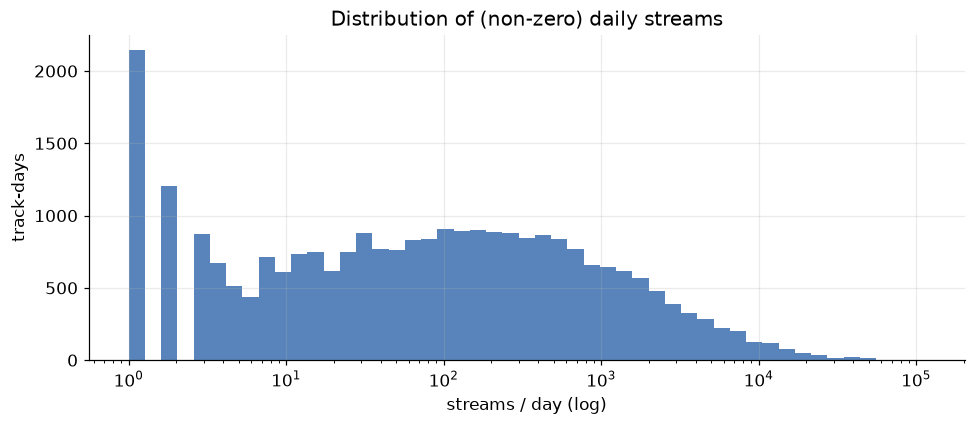

In [9]:
nz = panel.streams[panel.streams > 0]
desc = panel.streams.describe()
extra = pd.Series({"skew": panel.streams.skew(), "kurtosis": panel.streams.kurt(),
                   "% zero days": (panel.streams == 0).mean()*100})
display(pd.concat([desc, extra]).to_frame("daily streams").style.format("{:,.2f}"))

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(0, np.log10(nz.max()), 50)
ax.hist(nz, bins=bins, color="#3b6fb0", alpha=0.85)
ax.set_xscale("log"); ax.set_title("Distribution of (non-zero) daily streams")
ax.set_xlabel("streams / day (log)"); ax.set_ylabel("track-days")
plt.tight_layout(); plt.show()

## 9 · Concentration — do hits dominate?

Lorenz curve and Gini over **total streams per track**. The further the curve bows from the 45° line, the more lopsided the catalog.

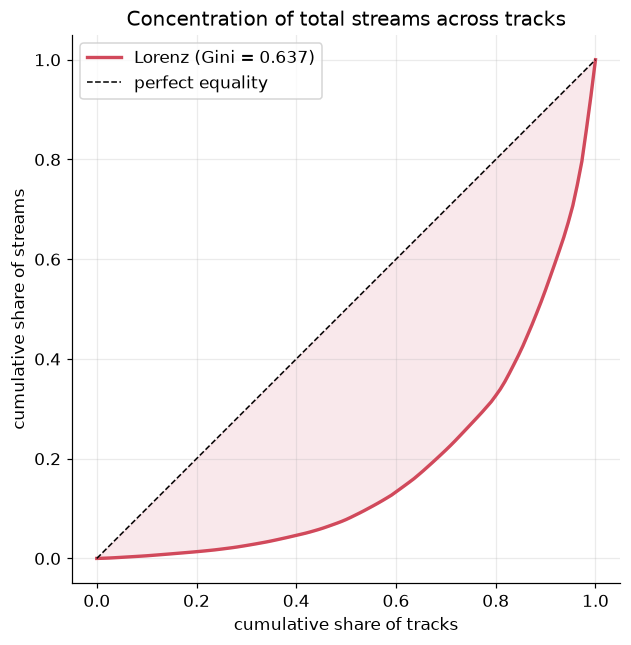

Gini coefficient: 0.637


,share of all streams
Top 1% of tracks,14.0%
Top 5% of tracks,32.6%
Top 10% of tracks,46.1%
Top 20% of tracks,67.4%


In [10]:
def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x)
    if x.sum() == 0: return 0.0
    return (2*np.sum((np.arange(1, n+1))*x) - (n+1)*x.sum()) / (n*x.sum())

tot = totals.sort_values().values
g = gini(tot)
cum = np.insert(np.cumsum(tot)/tot.sum(), 0, 0)
frac = np.linspace(0, 1, len(cum))

shares = pd.Series({
    "Top 1% of tracks":  tot[int(0.99*len(tot)):].sum()/tot.sum(),
    "Top 5% of tracks":  tot[int(0.95*len(tot)):].sum()/tot.sum(),
    "Top 10% of tracks": tot[int(0.90*len(tot)):].sum()/tot.sum(),
    "Top 20% of tracks": tot[int(0.80*len(tot)):].sum()/tot.sum(),
})

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(frac, cum, color="#d1495b", lw=2.2, label=f"Lorenz (Gini = {g:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="perfect equality")
ax.fill_between(frac, cum, frac, color="#d1495b", alpha=0.12)
ax.set_title("Concentration of total streams across tracks")
ax.set_xlabel("cumulative share of tracks"); ax.set_ylabel("cumulative share of streams")
ax.legend(loc="upper left"); ax.set_aspect("equal"); plt.tight_layout(); plt.show()

print(f"Gini coefficient: {g:.3f}")
display(shares.to_frame("share of all streams").style.format("{:.1%}"))

## 10 · Per-track summary table

Top and bottom of the catalog by lifetime streams.

In [11]:
per_track = (panel.groupby(["artist_id","track_id"])
             .agg(total_streams=("streams","sum"),
                  peak_day=("streams","max"),
                  days_active=("streams","size"))
             .reset_index()
             .merge(tracks[["track_id","release_date","half_life","quality"]], on="track_id")
             .sort_values("total_streams", ascending=False))
per_track["release_date"] = per_track.release_date.dt.date

print("Top 10 tracks"); display(per_track.head(10).style.format(
    {"total_streams":"{:,.0f}","peak_day":"{:,.0f}","half_life":"{:.1f}","quality":"{:.2f}"}))
print("Bottom 5 tracks"); display(per_track.tail(5).style.format(
    {"total_streams":"{:,.0f}","peak_day":"{:,.0f}","half_life":"{:.1f}","quality":"{:.2f}"}))

Top 10 tracks


,artist_id,track_id,total_streams,peak_day,days_active,release_date,half_life,quality
80,A22,T080,"1,569,917","45,444",586,2024-05-25,37.2,4.40
41,A11,T041,"1,453,297","113,582",92,2025-10-01,32.6,3.83
9,A02,T009,"1,380,897","95,834",276,2025-03-31,35.8,1.65
84,A22,T084,"1,011,896","36,647",286,2025-03-21,39.2,2.71
79,A22,T079,"907,633","29,403",497,2024-08-22,34.6,2.72
55,A15,T055,"721,634","11,746",431,2024-10-27,73.0,8.50
97,A27,T097,"654,524","25,946",208,2025-06-07,68.1,1.60
68,A18,T068,"581,506","53,553",26,2025-12-06,29.4,1.14
105,A28,T105,"573,140","59,438",131,2025-08-23,30.2,1.91
106,A28,T106,"558,529","84,446",406,2024-11-21,20.2,1.57


Bottom 5 tracks


,artist_id,track_id,total_streams,peak_day,days_active,release_date,half_life,quality
78,A21,T078,"11,454",370,203,2025-06-12,29.0,0.27
54,A15,T054,"10,352",734,195,2025-06-20,22.6,0.40
14,A05,T014,"8,048",568,232,2025-05-14,14.8,0.72
66,A17,T066,"6,953",336,223,2025-05-23,19.1,0.31
6,A01,T006,"5,137",253,333,2025-02-02,18.3,0.29


## 11 · Takeaways

- **Catalog growth + weekly ripple** — total daily streams trend up as releases
  accumulate, with a clean Friday/weekend seasonal cycle on top.
- **Release-and-decay** is the dominant track-level shape; averaging in event time
  recovers the injected exponential half-life almost exactly.
- **Over-dispersed, heavy-tailed counts** — most track-days are tiny, a few are huge.
- **Hits dominate** — a high Gini and a steep Lorenz curve: the top few percent of
  tracks account for the bulk of all streams, exactly the concentration we built
  from log-normal popularity × quality plus rare viral shocks.

### Knobs to play with
Re-run after editing the `P` config in §1:
`pop_sigma` / `qual_sigma` (more spread ⇒ higher Gini) · `halflife_med` (longer tails)
· `dow_raw` (seasonality shape) · `viral_*` (frequency/size of spikes) · `nb_r`
(noisiness) · `SEED` (a whole new world).

The tidy panel lives in `panel` (one row per track-day) and the release metadata in
`tracks` — export with `panel.to_csv(...)` / `panel.to_parquet(...)` to use elsewhere.
